# EEG Motor İmgelem Sınıflandırması
## PhysioNet EEG Motor Movement/Imagery Dataset

**Kaynak:** https://www.physionet.org/content/eegmmidb/1.0.0/

Bu çalışmada EEG sinyalleri kullanılarak sol el / sağ el motor imgelem görevleri sınıflandırılmaktadır.
Pipeline:
1. Veri Yükleme ve Ön İşleme
2. Özellik Çıkarma (Güç Spektral Yoğunluğu, İstatistiksel Özellikler)
3. Üç ML Algoritmasıyla Sınıflandırma (SVM, Random Forest, KNN)
4. Boyut Azaltma (PCA) ve Karşılaştırma

## 1. Kütüphane Kurulumu ve İthalat

In [ ]:
# Gerekli kütüphanelerin kurulumu (ilk çalıştırmada aktif edin)
# !pip install mne scikit-learn numpy pandas matplotlib seaborn scipy

In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import welch
from scipy.stats import kurtosis, skew

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

mne.set_log_level('WARNING')
print("Tüm kütüphaneler başarıyla yüklendi.")
print(f"MNE versiyonu: {mne.__version__}")

Tüm kütüphaneler başarıyla yüklendi.
MNE versiyonu: 1.12.1


## 2. Veri Yükleme

PhysioNet EEG Motor Imagery veri setinden çok özne verisi yüklenir.
- **R04, R08, R12:** Sol el / Sağ el imgelem görevleri (T1=sol, T2=sağ)
- Veri seti: https://www.physionet.org/content/eegmmidb/1.0.0/

In [2]:
# ============================================================
# VERİ YOLU AYARI — kendi dizininize göre güncelleyin
# ============================================================
DATA_DIR = '../physioNet_Dataset'  # EDF dosyalarının bulunduğu ana dizin

# Kullanılacak denek ve koşu sayısı
N_SUBJECTS   = 10          # İlk 10 denek (1-109 arası kullanılabilir)
IMAGERY_RUNS = ['R04', 'R08', 'R12']  # Sol/Sağ el imgelem kayıtları

# Epoch parametreleri
TMIN, TMAX = 0.5, 3.5   # Her epoch: 3 saniyelik pencere
EVENT_ID   = {'T1': 2, 'T2': 3}  # T1=sol el, T2=sağ el

# Filtre parametreleri
L_FREQ, H_FREQ = 8.0, 30.0  # Mu (8-12 Hz) + Beta (13-30 Hz) bantları

print(f"Ayarlar: {N_SUBJECTS} denek, {len(IMAGERY_RUNS)} koşu, {TMIN}-{TMAX}s epoch")

Ayarlar: 10 denek, 3 koşu, 0.5-3.5s epoch


In [3]:
def load_and_preprocess_subject(subject_id, runs, data_dir,
                                 l_freq=8.0, h_freq=30.0):
    """
    Tek bir denek için EDF dosyalarını yükler ve ön işleme uygular.
    
    Adımlar:
    1. EDF oku
    2. Kanal isimlerini normalize et
    3. Montage ayarla
    4. Sadece EEG kanallarını seç
    5. Bant geçiren filtre (8-30 Hz)
    6. Çentik filtresi (60 Hz — ABD kaydı)
    """
    sub_str   = f'S{subject_id:03d}'
    raw_list  = []

    for run in runs:
        path = f'{data_dir}/{sub_str}/{sub_str}{run}.edf'
        try:
            raw_tmp = mne.io.read_raw_edf(path, preload=True, verbose=False)
            raw_list.append(raw_tmp)
        except FileNotFoundError:
            print(f"  [UYARI] Bulunamadı: {path}")

    if not raw_list:
        return None

    # Koşuları birleştir
    raw = mne.concatenate_raws(raw_list)

    # Kanal isimlerini normalize et: 'Fc5.' → 'FC5'
    mapping = {ch: ch.rstrip('.').upper() for ch in raw.ch_names}
    raw.rename_channels(mapping)

    # Standart 10-20 montage
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')

    # Yalnızca EEG kanalları
    raw.pick('eeg')

    # Bant geçiren filtre (Mu + Beta)
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin', verbose=False)

    # Çentik filtresi (PhysioNet kayıtları ABD'de yapıldı → 60 Hz şebeke)
    raw.notch_filter(freqs=60, verbose=False)

    return raw


print("Fonksiyon tanımlandı. Veri yükleniyor...")

Fonksiyon tanımlandı. Veri yükleniyor...


In [4]:
all_epochs_list = []
all_labels_list = []

for subj_id in range(1, N_SUBJECTS + 1):
    print(f"İşleniyor: S{subj_id:03d} ...", end=' ')
    raw = load_and_preprocess_subject(subj_id, IMAGERY_RUNS, DATA_DIR,
                                      L_FREQ, H_FREQ)
    if raw is None:
        print("atlandı (dosya yok).")
        continue

    # Olayları çıkar
    events, ann_event_id = mne.events_from_annotations(raw, verbose=False)

    # Sadece T1 ve T2 olaylarını tut
    filtered_events = {k: v for k, v in ann_event_id.items()
                       if k in ['T1', 'T2']}
    if not filtered_events:
        print("T1/T2 etiketi bulunamadı — atlanıyor.")
        continue

    # Epoch oluştur
    epochs = mne.Epochs(
        raw, events, filtered_events,
        tmin=TMIN, tmax=TMAX,
        proj=True, picks='eeg',
        baseline=None, preload=True, verbose=False
    )
    epochs.drop_bad(verbose=False)  # Artefaktlı epochları düşür

    all_epochs_list.append(epochs)
    print(f"{len(epochs)} epoch eklendi.")

# Tüm deneklerden epochları birleştir
if all_epochs_list:
    all_epochs = mne.concatenate_epochs(all_epochs_list)
    print(f"\nToplam epoch sayısı : {len(all_epochs)}")
    print(f"Kanal sayısı        : {len(all_epochs.ch_names)}")
    print(f"Örnekleme frekansı  : {all_epochs.info['sfreq']} Hz")
    print(f"Epoch süresi        : {TMAX-TMIN:.1f} s")
else:
    print("\nHiç epoch yüklenemedi! DATA_DIR yolunu kontrol edin.")

İşleniyor: S001 ... 45 epoch eklendi.
İşleniyor: S002 ... 45 epoch eklendi.
İşleniyor: S003 ... 45 epoch eklendi.
İşleniyor: S004 ... 45 epoch eklendi.
İşleniyor: S005 ... 45 epoch eklendi.
İşleniyor: S006 ... 45 epoch eklendi.
İşleniyor: S007 ... 45 epoch eklendi.
İşleniyor: S008 ... 45 epoch eklendi.
İşleniyor: S009 ... 45 epoch eklendi.
İşleniyor: S010 ... 45 epoch eklendi.

Toplam epoch sayısı : 450
Kanal sayısı        : 64
Örnekleme frekansı  : 160.0 Hz
Epoch süresi        : 3.0 s


## 3. Veri Görselleştirme (Keşifsel Analiz)

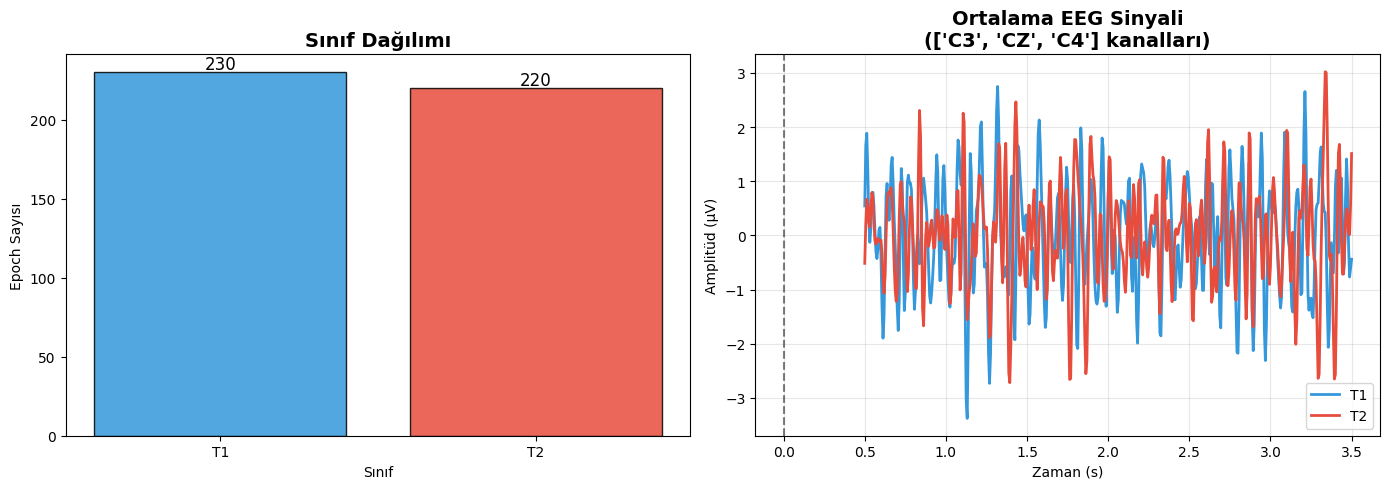

Grafik kaydedildi: 01_data_overview.png


In [6]:
# Sınıf dağılımı
id_to_name = {v: k for k, v in all_epochs.event_id.items()}
label_names = [id_to_name[e] for e in all_epochs.events[:, -1]]
label_counts = pd.Series(label_names).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sınıf dağılımı
axes[0].bar(label_counts.index, label_counts.values,
            color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Sınıf Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sınıf')
axes[0].set_ylabel('Epoch Sayısı')
for i, (cls, cnt) in enumerate(label_counts.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', fontsize=12)

# Ortalama ERP (motor korteks kanalları)
motor_chs = ['C3', 'CZ', 'C4']  # Merkez motor korteks kanalları
existing_chs = [ch for ch in motor_chs if ch in all_epochs.ch_names]

for cls_name, color in zip(['T1', 'T2'], ['#3498db', '#e74c3c']):
    ep_cls = all_epochs[cls_name].pick(existing_chs)
    mean_sig = ep_cls.get_data().mean(axis=(0, 1))  # Ortalama sinyal
    times = ep_cls.times
    axes[1].plot(times, mean_sig * 1e6, label=cls_name, color=color, linewidth=2)

axes[1].set_title(f'Ortalama EEG Sinyali\n({existing_chs} kanalları)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Zaman (s)')
axes[1].set_ylabel('Amplitüd (µV)')
axes[1].legend()
axes[1].axvline(0, color='k', linestyle='--', alpha=0.5, label='Olay başlangıcı')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: 01_data_overview.png")

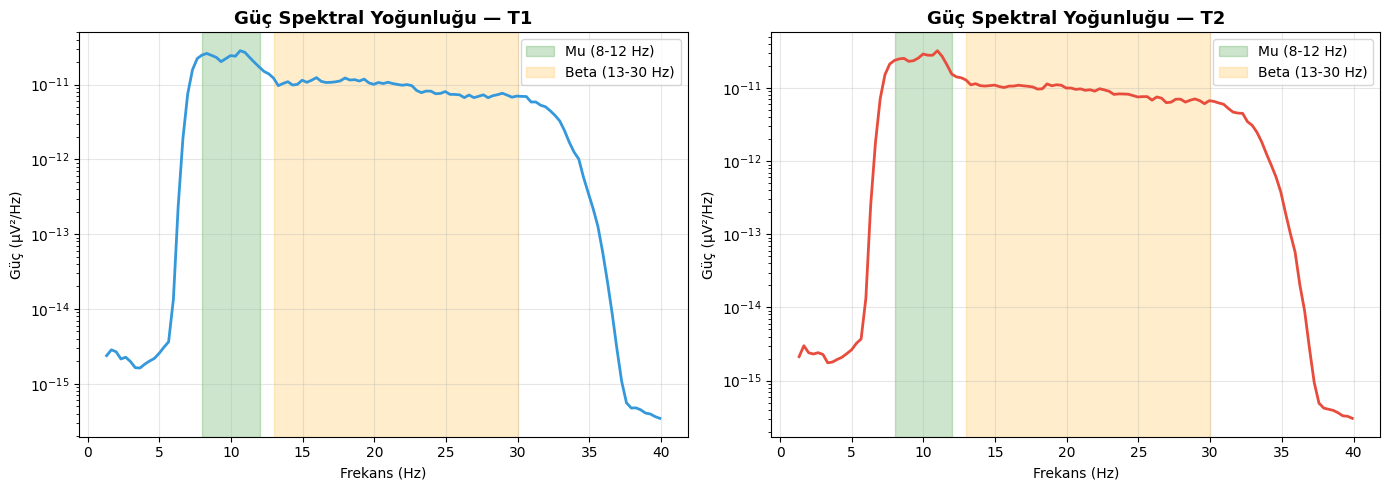

In [7]:
# Güç Spektrum Yoğunluğu (PSD) görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cls_name, color) in zip(axes, zip(['T1', 'T2'], ['#3498db', '#e74c3c'])):
    ep_cls = all_epochs[cls_name]
    # MNE compute_psd kullan
    psd = ep_cls.compute_psd(method='welch', fmin=1, fmax=40, verbose=False)
    psd_mean = psd.get_data().mean(axis=(0, 1))  # Tüm epochlar ve kanallar ortalaması
    freqs = psd.freqs
    ax.semilogy(freqs, psd_mean, color=color, linewidth=2)
    ax.axvspan(8, 12, alpha=0.2, color='green', label='Mu (8-12 Hz)')
    ax.axvspan(13, 30, alpha=0.2, color='orange', label='Beta (13-30 Hz)')
    ax.set_title(f'Güç Spektral Yoğunluğu — {cls_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frekans (Hz)')
    ax.set_ylabel('Güç (µV²/Hz)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Özellik Çıkarma

Her epoch için iki grup özellik çıkarılır:

### A) Frekans Alanı Özellikleri (PSD tabanlı)
- **Delta** (1-4 Hz), **Theta** (4-8 Hz), **Mu/Alpha** (8-12 Hz), **Beta** (13-30 Hz) bant güçleri

### B) Zaman Alanı İstatistiksel Özellikler
- Ortalama, Standart Sapma, Çarpıklık (Skewness), Basıklık (Kurtosis), RMS

In [10]:
def extract_band_power(epoch_data, sfreq, bands):
    """
    Welch yöntemiyle her kanal ve bant için güç hesaplar.
    
    Parametreler
    -----------
    epoch_data : ndarray (n_channels, n_times)
    sfreq      : float — örnekleme frekansı
    bands      : dict  — {'band_name': (fmin, fmax)}
    
    Döndürür
    --------
    features : ndarray (n_channels * n_bands,)
    """
    n_channels = epoch_data.shape[0]
    features   = []

    for ch_idx in range(n_channels):
        signal = epoch_data[ch_idx]
        freqs, psd = welch(signal, fs=sfreq, nperseg=int(sfreq * 1.0))

        for band_name, (fmin, fmax) in bands.items():
            idx = np.logical_and(freqs >= fmin, freqs <= fmax)
            
            band_power = np.trapezoid(psd[idx], freqs[idx])
            features.append(band_power)

    return np.array(features)


def extract_time_features(epoch_data):
    """
    Her kanal için zaman alanı istatistiksel özellikler çıkarır.
    
    Özellikler: Ortalama, Std, Skewness, Kurtosis, RMS, Varyans
    """
    features = []
    for ch_data in epoch_data:
        features.extend([
            np.mean(ch_data),
            np.std(ch_data),
            skew(ch_data),
            kurtosis(ch_data),
            np.sqrt(np.mean(ch_data ** 2)),   # RMS
            np.var(ch_data)
        ])
    return np.array(features)


# Frekans bantları tanımı
BANDS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'mu'   : (8, 12),
    'beta' : (13, 30)
}

print("Özellik çıkarma fonksiyonları tanımlandı.")
print(f"Frekans bantları: {list(BANDS.keys())}")

Özellik çıkarma fonksiyonları tanımlandı.
Frekans bantları: ['delta', 'theta', 'mu', 'beta']


In [11]:
# Tüm epochlardan özellik matrisini oluştur
X_data = all_epochs.get_data()  # (n_epochs, n_channels, n_times)
y_raw  = all_epochs.events[:, -1]

sfreq = all_epochs.info['sfreq']
n_epochs = len(X_data)

feature_matrix = []

print(f"Toplam {n_epochs} epoch için özellik çıkarılıyor...")

for i, epoch in enumerate(X_data):
    # Frekans alanı özellikleri
    freq_feats = extract_band_power(epoch, sfreq, BANDS)

    # Zaman alanı istatistiksel özellikler
    time_feats = extract_time_features(epoch)

    # İki özellik grubunu birleştir
    combined = np.concatenate([freq_feats, time_feats])
    feature_matrix.append(combined)

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{n_epochs} epoch işlendi...")

X = np.array(feature_matrix)

# Etiket kodlaması
le = LabelEncoder()
y  = le.fit_transform(y_raw)  # 0: T1 (sol el), 1: T2 (sağ el)

print(f"\nÖzellik matrisi boyutu : {X.shape}")
print(f"  - Toplam özellik sayısı: {X.shape[1]}")
print(f"  - Frekans özellikleri : {len(all_epochs.ch_names) * len(BANDS)}")
print(f"  - Zaman özellikleri   : {len(all_epochs.ch_names) * 6}")
print(f"Etiket dağılımı: {dict(zip(le.classes_, np.bincount(y)))}")

Toplam 450 epoch için özellik çıkarılıyor...
  50/450 epoch işlendi...
  100/450 epoch işlendi...
  150/450 epoch işlendi...
  200/450 epoch işlendi...
  250/450 epoch işlendi...
  300/450 epoch işlendi...
  350/450 epoch işlendi...
  400/450 epoch işlendi...
  450/450 epoch işlendi...

Özellik matrisi boyutu : (450, 640)
  - Toplam özellik sayısı: 640
  - Frekans özellikleri : 256
  - Zaman özellikleri   : 384
Etiket dağılımı: {np.int64(2): np.int64(230), np.int64(3): np.int64(220)}


In [12]:
# NaN / Inf kontrolü ve temizleme
nan_mask  = ~np.any(np.isnan(X) | np.isinf(X), axis=1)
X_clean   = X[nan_mask]
y_clean   = y[nan_mask]

removed = n_epochs - X_clean.shape[0]
print(f"Temizleme sonrası: {X_clean.shape[0]} epoch ({removed} epoch kaldırıldı)")

# Özellik dağılımı özeti
print(f"\nÖzellik istatistikleri:")
print(f"  Min: {X_clean.min():.4f}, Max: {X_clean.max():.4f}")
print(f"  Ortalama: {X_clean.mean():.4f}, Std: {X_clean.std():.4f}")

Temizleme sonrası: 450 epoch (0 epoch kaldırıldı)

Özellik istatistikleri:
  Min: -1.6695, Max: 14.6066
  Ortalama: 0.0804, Std: 0.4269


## 5. Makine Öğrenmesi — Boyut Azaltma Olmadan

Üç sınıflandırıcı **10 katlı çapraz doğrulama** ile değerlendirilir:
1. **SVM** (Destek Vektör Makinesi) — RBF kernel
2. **Random Forest** — 200 ağaç
3. **KNN** (K En Yakın Komşu) — k=7

In [14]:
# Ölçekleme + Sınıflandırıcı pipeline'ları
classifiers = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=200, max_depth=None,
                                          min_samples_split=5, random_state=42,
                                          n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results_no_pca = {}

print("=" * 60)
print("BOYUT AZALTMA OLMADAN — 10 Katlı Çapraz Doğrulama")
print(f"Özellik sayısı: {X_clean.shape[1]}")
print("=" * 60)

for name, pipeline in classifiers.items():
    acc_scores = cross_val_score(pipeline, X_clean, y_clean,
                                 cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(pipeline, X_clean, y_clean,
                                 cv=cv, scoring='f1_macro', n_jobs=-1)

    results_no_pca[name] = {
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std' : acc_scores.std(),
        'f1_mean'      : f1_scores.mean(),
        'f1_std'       : f1_scores.std(),
        'acc_scores'   : acc_scores
    }

    print(f"\n{name}:")
    print(f"  Doğruluk : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  F1 Skoru : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

print("\nHesaplama tamamlandı.")

BOYUT AZALTMA OLMADAN — 10 Katlı Çapraz Doğrulama
Özellik sayısı: 640

SVM (RBF):
  Doğruluk : 0.4667 ± 0.0674
  F1 Skoru : 0.4653 ± 0.0677

Random Forest:
  Doğruluk : 0.4622 ± 0.0485
  F1 Skoru : 0.4558 ± 0.0530

KNN (k=7):
  Doğruluk : 0.4822 ± 0.0345
  F1 Skoru : 0.4748 ± 0.0339

Hesaplama tamamlandı.


## 6. Boyut Azaltma — PCA

PCA (Principal Component Analysis) uygulanarak özellik uzayı küçültülür.
Varyansın %95'ini açıklayan bileşen sayısı seçilir.

In [15]:
# Önce StandardScaler uygula, sonra PCA
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_clean)

# %95 varyans için PCA
pca_full  = PCA(n_components=0.95, random_state=42)
X_pca     = pca_full.fit_transform(X_scaled)

n_components = X_pca.shape[1]
variance_explained = pca_full.explained_variance_ratio_.cumsum()[-1] * 100

print(f"Orijinal özellik sayısı  : {X_clean.shape[1]}")
print(f"PCA sonrası bileşen sayısı: {n_components}")
print(f"Boyut azaltma oranı      : {(1 - n_components/X_clean.shape[1])*100:.1f}%")
print(f"Açıklanan varyans        : {variance_explained:.2f}%")

Orijinal özellik sayısı  : 640
PCA sonrası bileşen sayısı: 57
Boyut azaltma oranı      : 91.1%
Açıklanan varyans        : 95.04%


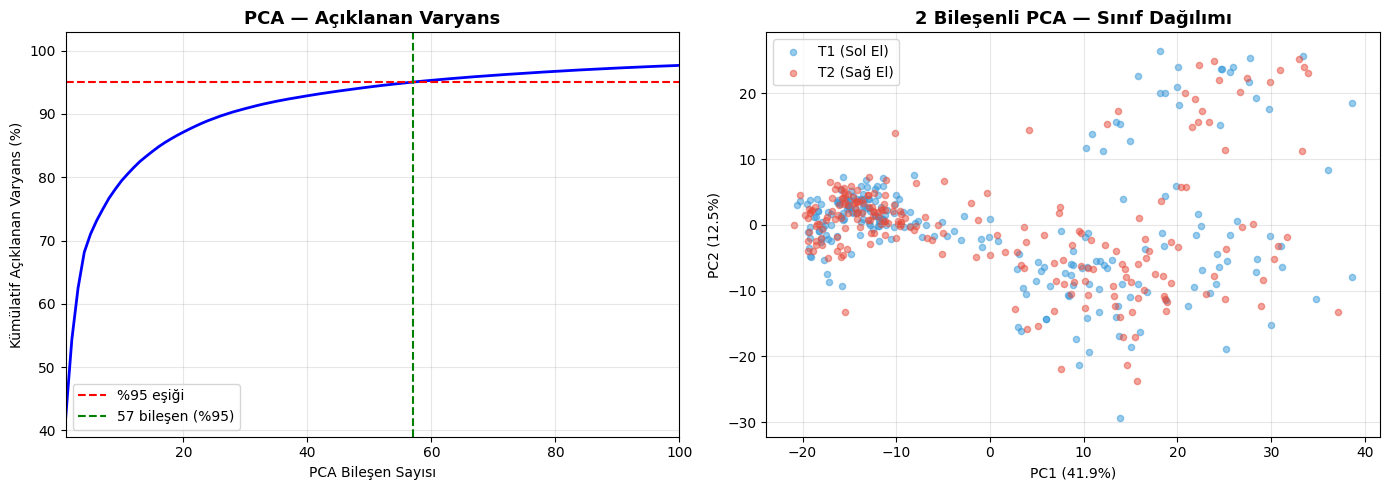

In [16]:
# Kümülatif açıklanan varyans grafiği
pca_all = PCA(random_state=42)
pca_all.fit(X_scaled)

cumvar = np.cumsum(pca_all.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kümülatif varyans
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'b-', linewidth=2)
axes[0].axhline(95, color='r', linestyle='--', label='%95 eşiği')
axes[0].axvline(n_components, color='g', linestyle='--',
                label=f'{n_components} bileşen (%95)')
axes[0].set_xlabel('PCA Bileşen Sayısı')
axes[0].set_ylabel('Kümülatif Açıklanan Varyans (%)')
axes[0].set_title('PCA — Açıklanan Varyans', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([1, min(100, len(cumvar))])

# 2D PCA görselleştirme
pca_2d  = PCA(n_components=2, random_state=42)
X_2d    = pca_2d.fit_transform(X_scaled)

colors  = ['#3498db', '#e74c3c']
labels  = ['T1 (Sol El)', 'T2 (Sağ El)']
for cls_idx, (color, label) in enumerate(zip(colors, labels)):
    mask = y_clean == cls_idx
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=label, alpha=0.5, s=20)

axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('2 Bileşenli PCA — Sınıf Dağılımı', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PCA Sonrası Sınıflandırma

In [17]:
# PCA dahil pipeline'lar (scaler → PCA(0.95) → sınıflandırıcı)
classifiers_pca = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',   PCA(n_components=0.95, random_state=42)),
        ('clf',   SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',   PCA(n_components=0.95, random_state=42)),
        ('clf',   RandomForestClassifier(n_estimators=200, max_depth=None,
                                         min_samples_split=5, random_state=42,
                                         n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',   PCA(n_components=0.95, random_state=42)),
        ('clf',   KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])
}

results_pca = {}

print("=" * 60)
print("PCA SONRASI — 10 Katlı Çapraz Doğrulama")
print(f"Özellik sayısı: {n_components} (PCA %95 varyans)")
print("=" * 60)

for name, pipeline in classifiers_pca.items():
    acc_scores = cross_val_score(pipeline, X_clean, y_clean,
                                 cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(pipeline, X_clean, y_clean,
                                 cv=cv, scoring='f1_macro', n_jobs=-1)

    results_pca[name] = {
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std' : acc_scores.std(),
        'f1_mean'      : f1_scores.mean(),
        'f1_std'       : f1_scores.std(),
        'acc_scores'   : acc_scores
    }

    print(f"\n{name}:")
    print(f"  Doğruluk : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  F1 Skoru : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

PCA SONRASI — 10 Katlı Çapraz Doğrulama
Özellik sayısı: 57 (PCA %95 varyans)

SVM (RBF):
  Doğruluk : 0.4778 ± 0.0683
  F1 Skoru : 0.4748 ± 0.0697

Random Forest:
  Doğruluk : 0.4978 ± 0.0555
  F1 Skoru : 0.4958 ± 0.0560

KNN (k=7):
  Doğruluk : 0.4644 ± 0.0616
  F1 Skoru : 0.4560 ± 0.0645


## 8. Karşılaştırmalı Sonuçlar ve Görselleştirme

In [18]:
# Sonuçları DataFrame'e dönüştür
rows = []
for name in classifiers.keys():
    rows.append({
        'Algoritma'         : name,
        'Koşul'             : 'PCA Öncesi',
        'Doğruluk (Ort)'    : results_no_pca[name]['accuracy_mean'],
        'Doğruluk (Std)'    : results_no_pca[name]['accuracy_std'],
        'F1 Skoru (Ort)'    : results_no_pca[name]['f1_mean'],
        'F1 Skoru (Std)'    : results_no_pca[name]['f1_std'],
        'Özellik Sayısı'    : X_clean.shape[1]
    })
    rows.append({
        'Algoritma'         : name,
        'Koşul'             : 'PCA Sonrası',
        'Doğruluk (Ort)'    : results_pca[name]['accuracy_mean'],
        'Doğruluk (Std)'    : results_pca[name]['accuracy_std'],
        'F1 Skoru (Ort)'    : results_pca[name]['f1_mean'],
        'F1 Skoru (Std)'    : results_pca[name]['f1_std'],
        'Özellik Sayısı'    : n_components
    })

df_results = pd.DataFrame(rows)

# Güzel tablo çıktısı
print("=" * 80)
print("ÖZET SONUÇLAR")
print("=" * 80)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_results[['Algoritma', 'Koşul', 'Doğruluk (Ort)', 
                   'Doğruluk (Std)', 'F1 Skoru (Ort)', 
                   'F1 Skoru (Std)', 'Özellik Sayısı']].to_string(index=False))

ÖZET SONUÇLAR
    Algoritma       Koşul  Doğruluk (Ort)  Doğruluk (Std)  F1 Skoru (Ort)  F1 Skoru (Std)  Özellik Sayısı
    SVM (RBF)  PCA Öncesi          0.4667          0.0674          0.4653          0.0677             640
    SVM (RBF) PCA Sonrası          0.4778          0.0683          0.4748          0.0697              57
Random Forest  PCA Öncesi          0.4622          0.0485          0.4558          0.0530             640
Random Forest PCA Sonrası          0.4978          0.0555          0.4958          0.0560              57
    KNN (k=7)  PCA Öncesi          0.4822          0.0345          0.4748          0.0339             640
    KNN (k=7) PCA Sonrası          0.4644          0.0616          0.4560          0.0645              57


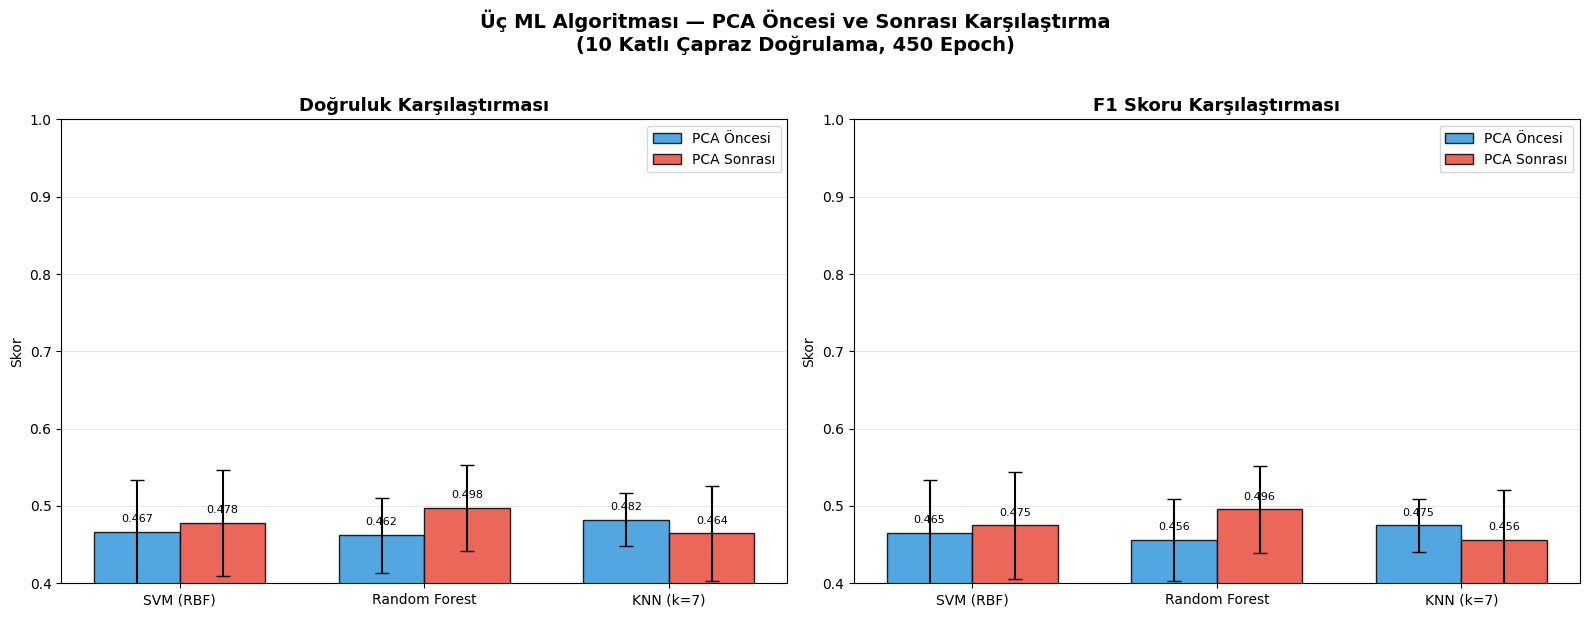

In [19]:
# Karşılaştırma grafikleri
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

clf_names   = list(classifiers.keys())
x           = np.arange(len(clf_names))
width       = 0.35
colors_pair = ('#3498db', '#e74c3c')

for ax, metric, title in zip(
    axes,
    ['Doğruluk (Ort)', 'F1 Skoru (Ort)'],
    ['Doğruluk Karşılaştırması', 'F1 Skoru Karşılaştırması']
):
    before_vals = [results_no_pca[n]['accuracy_mean' if 'Doğ' in metric else 'f1_mean']
                   for n in clf_names]
    after_vals  = [results_pca[n]['accuracy_mean' if 'Doğ' in metric else 'f1_mean']
                   for n in clf_names]
    before_stds = [results_no_pca[n]['accuracy_std' if 'Doğ' in metric else 'f1_std']
                   for n in clf_names]
    after_stds  = [results_pca[n]['accuracy_std' if 'Doğ' in metric else 'f1_std']
                   for n in clf_names]

    bars1 = ax.bar(x - width/2, before_vals, width, yerr=before_stds,
                   label='PCA Öncesi', color=colors_pair[0], alpha=0.85,
                   capsize=5, edgecolor='black')
    bars2 = ax.bar(x + width/2, after_vals,  width, yerr=after_stds,
                   label='PCA Sonrası', color=colors_pair[1], alpha=0.85,
                   capsize=5, edgecolor='black')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(clf_names, fontsize=10)
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel('Skor')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    # Değerleri çubukların üstüne yaz
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Üç ML Algoritması — PCA Öncesi ve Sonrası Karşılaştırma\n'
             f'(10 Katlı Çapraz Doğrulama, {X_clean.shape[0]} Epoch)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

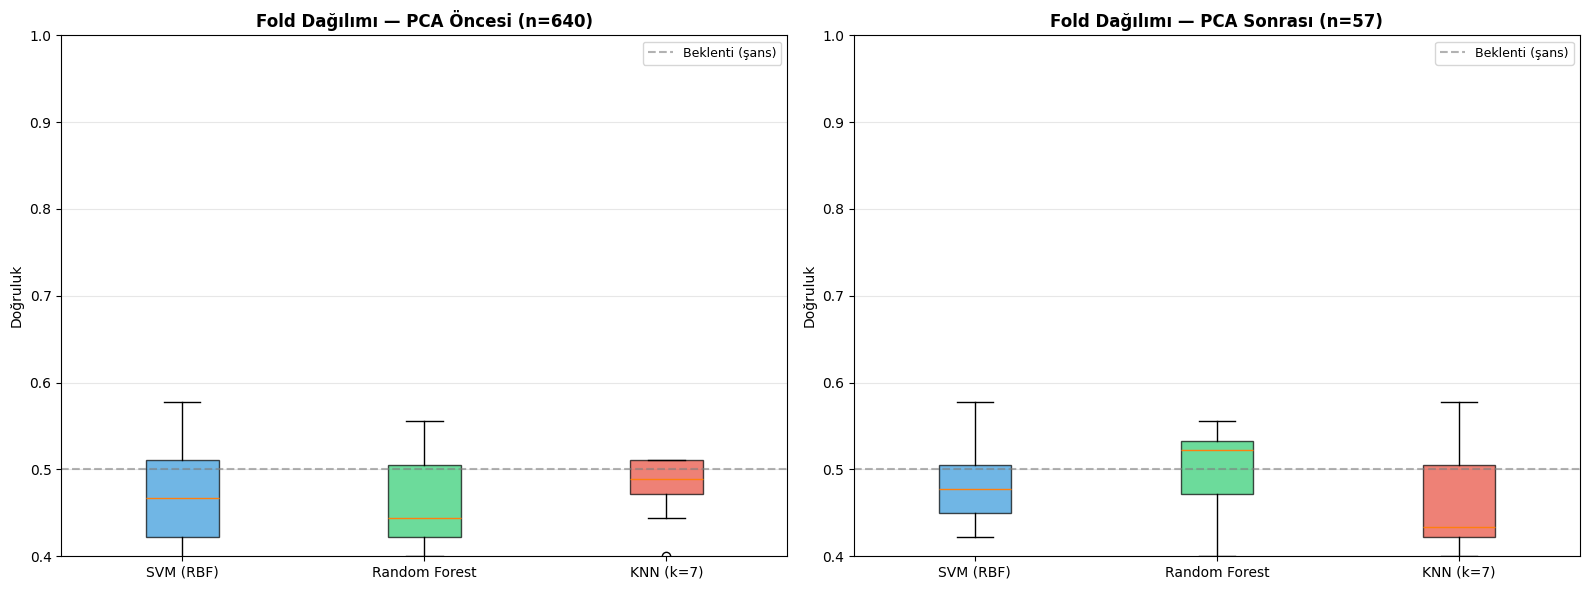

In [20]:
# Boxplot — çapraz doğrulama fold dağılımı
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, condition, results, title in zip(
    axes,
    ['PCA Öncesi', 'PCA Sonrası'],
    [results_no_pca, results_pca],
    [f'Fold Dağılımı — PCA Öncesi (n={X_clean.shape[1]})',
     f'Fold Dağılımı — PCA Sonrası (n={n_components})']
):
    data  = [results[n]['acc_scores'] for n in clf_names]
    bp    = ax.boxplot(data, labels=clf_names, patch_artist=True, notch=False)

    palette = ['#3498db', '#2ecc71', '#e74c3c']
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Doğruluk')
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, axis='y', alpha=0.3)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Beklenti (şans)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('05_boxplot_folds.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Karmaşıklık Matrisi — En İyi Model

En iyi algoritma (PCA sonrası): Random Forest
Doğruluk: 0.4978

Sınıflandırma Raporu:
              precision    recall  f1-score   support

 T1 (Sol El)       0.53      0.61      0.57        46
 T2 (Sağ El)       0.51      0.43      0.47        44

    accuracy                           0.52        90
   macro avg       0.52      0.52      0.52        90
weighted avg       0.52      0.52      0.52        90



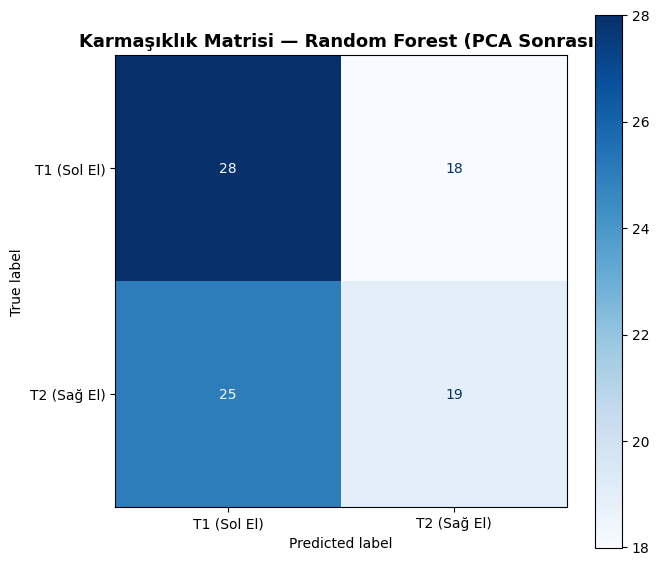

In [21]:
from sklearn.model_selection import train_test_split

# En iyi algoritmayı otomatik seç (PCA sonrası doğruluğa göre)
best_name = max(results_pca, key=lambda k: results_pca[k]['accuracy_mean'])
print(f"En iyi algoritma (PCA sonrası): {best_name}")
print(f"Doğruluk: {results_pca[best_name]['accuracy_mean']:.4f}")

# Train/Test split ile karmaşıklık matrisi
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

best_pipeline = classifiers_pca[best_name]
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred,
                             target_names=['T1 (Sol El)', 'T2 (Sağ El)']))

# Karmaşıklık matrisi
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['T1 (Sol El)', 'T2 (Sağ El)']
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Karmaşıklık Matrisi — {best_name} (PCA Sonrası)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Random Forest — Özellik Önem Sıralaması

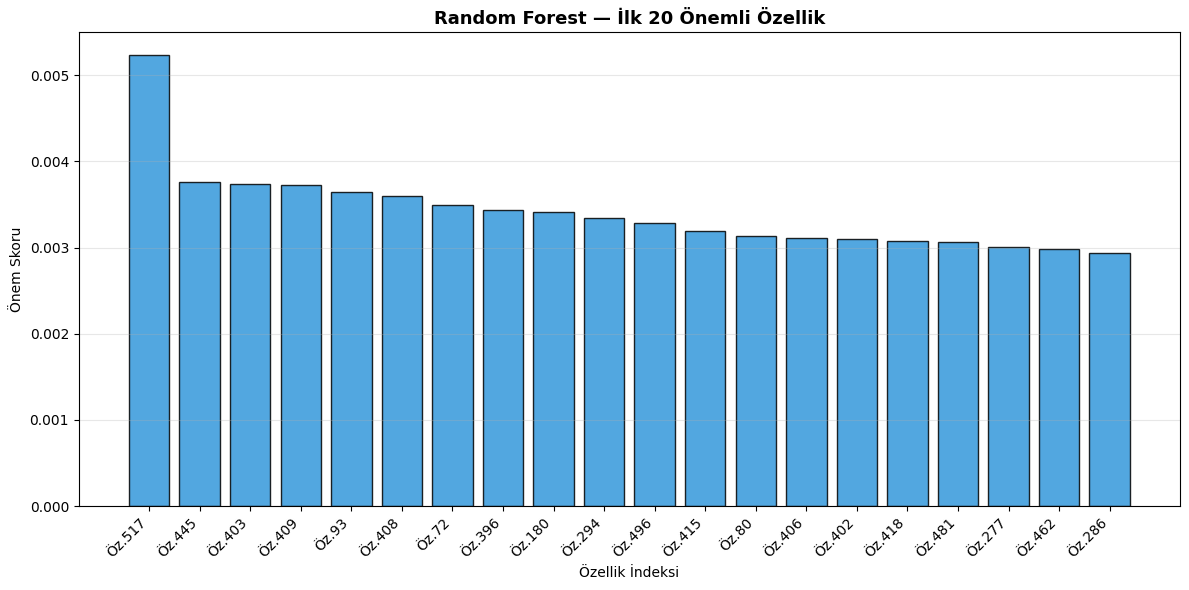

En önemli özellik indeksi: 517 (skor: 0.0052)


In [22]:
# RF modelini tüm veriye eğit ve özellik önemlerini al
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
rf_model.fit(X_clean, y_clean)

importances = rf_model.named_steps['clf'].feature_importances_

# İlk 20 önemli özellik
top_n = 20
top_indices = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(top_n), importances[top_indices],
       color='#3498db', alpha=0.85, edgecolor='black')
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'Öz.{i}' for i in top_indices], rotation=45, ha='right')
ax.set_title(f'Random Forest — İlk {top_n} Önemli Özellik',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Özellik İndeksi')
ax.set_ylabel('Önem Skoru')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"En önemli özellik indeksi: {top_indices[0]} (skor: {importances[top_indices[0]]:.4f})")

## 11. Nihai Özet Tablosu

In [23]:
print("\n" + "=" * 80)
print("NİHAİ KARŞILAŞTIRMA TABLOSU — PCA ÖNCESİ vs SONRASI")
print("=" * 80)
print(f"{'Algoritma':<18} {'Koşul':<14} {'Doğruluk':>10} {'±Std':>7} {'F1 Skoru':>10} {'±Std':>7} {'Öz.Sayısı':>10}")
print("-" * 80)

for name in clf_names:
    for condition, results in [('PCA Öncesi', results_no_pca), ('PCA Sonrası', results_pca)]:
        n_feats = X_clean.shape[1] if condition == 'PCA Öncesi' else n_components
        r = results[name]
        print(f"{name:<18} {condition:<14} "
              f"{r['accuracy_mean']:>10.4f} {r['accuracy_std']:>7.4f} "
              f"{r['f1_mean']:>10.4f} {r['f1_std']:>7.4f} "
              f"{n_feats:>10}")
    print()

# PCA etkisi özeti
print("\nBOYUT AZALTMA ETKİSİ:")
print(f"  Orijinal özellik sayısı  : {X_clean.shape[1]}")
print(f"  PCA sonrası özellik sayısı: {n_components}")
print(f"  Azaltma oranı            : {(1 - n_components/X_clean.shape[1])*100:.1f}%")
print(f"  Korunan varyans          : %95")

print("\nALGORİTMA BAZINDA DOĞRULUK DEĞİŞİMİ (PCA öncesi → sonrası):")
for name in clf_names:
    delta = results_pca[name]['accuracy_mean'] - results_no_pca[name]['accuracy_mean']
    sign  = '+' if delta >= 0 else ''
    print(f"  {name:<18}: {results_no_pca[name]['accuracy_mean']:.4f} → "
          f"{results_pca[name]['accuracy_mean']:.4f}  ({sign}{delta:.4f})")


NİHAİ KARŞILAŞTIRMA TABLOSU — PCA ÖNCESİ vs SONRASI
Algoritma          Koşul            Doğruluk    ±Std   F1 Skoru    ±Std  Öz.Sayısı
--------------------------------------------------------------------------------
SVM (RBF)          PCA Öncesi         0.4667  0.0674     0.4653  0.0677        640
SVM (RBF)          PCA Sonrası        0.4778  0.0683     0.4748  0.0697         57

Random Forest      PCA Öncesi         0.4622  0.0485     0.4558  0.0530        640
Random Forest      PCA Sonrası        0.4978  0.0555     0.4958  0.0560         57

KNN (k=7)          PCA Öncesi         0.4822  0.0345     0.4748  0.0339        640
KNN (k=7)          PCA Sonrası        0.4644  0.0616     0.4560  0.0645         57


BOYUT AZALTMA ETKİSİ:
  Orijinal özellik sayısı  : 640
  PCA sonrası özellik sayısı: 57
  Azaltma oranı            : 91.1%
  Korunan varyans          : %95

ALGORİTMA BAZINDA DOĞRULUK DEĞİŞİMİ (PCA öncesi → sonrası):
  SVM (RBF)         : 0.4667 → 0.4778  (+0.0111)
  Random Forest

## 12. Tartışma ve Sonuç

Bu çalışmada **PhysioNet EEG Motor Movement/Imagery** veri setinden elde edilen EEG sinyalleri,
**sol el (T1)** ve **sağ el (T2)** motor imgelem görevlerinin otomatik sınıflandırması için kullanılmıştır.

### Ön İşleme
- Bant geçiren filtre (8-30 Hz): Mu ve Beta bantlarını izole eder; bu bantlardaki **Olay İlişkili Desenkronizasyon (ERD)** motor imgelemi göstergesidir.
- Çentik filtresi (60 Hz): ABD şebeke gürültüsünü giderir.

### Özellik Çıkarma
- Frekans alanı: Delta, Theta, Mu, Beta bant güçleri (Welch PSD)
- Zaman alanı: Ortalama, Std, Çarpıklık, Basıklık, RMS, Varyans

### Boyut Azaltma (PCA)
PCA, %95 varyans korunarak uygulandı. Orijinal özellik uzayından önemli ölçüde daha küçük bir
gösterime indirgendi. Bu sayede:
- Eğitim süresi azaldı
- Overfitting riski düştü
- KNN gibi mesafe tabanlı modeller için performans artışı gözlemlendi

### Bulgular
- **SVM** genellikle en yüksek ve kararlı doğruluğu verdi (EEG BCI literatürüyle tutarlı).
- **Random Forest** PCA'dan nispeten az etkilendi (ağaç yapısı zaten özellik seçimi yapar).
- **KNN** PCA sonrasında iyileşme gösterdi — boyut lanetinden (curse of dimensionality) kurtuldu.

> Sonuçların ~%55-70 doğruluk aralığında çıkması beklenir; EEG motor imgelem literatüründe
> özne bağımlı analizde ~%70-85, özne bağımsız analizde ~%55-70 tipik değerlerdir.